<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/francisco/francisco_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Parte 2: Análisis exploratorio y curación de datos

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*

**Entrega individual:** Francisco Capobianco

**Objetivo**: responder al menos tres de las preguntas planteadas por el grupo en el trabajo práctico 1.

Se espera un manejo más avanzado del set de datos, en donde el grupo de trabajo relacione las distintas columnas del dataset (variables) para responder preguntas con una complejidad mayor que la de realizar una mera descripción.

Cada respuesta a cada pregunta contiene: (1) el planteo de la pregunta y sus implicancias, (2) el desarrollo paso a paso, y (3) al menos un gráfico con su interpretación.

## Preguntas planteadas en el TP1 (grupal)

En el TP1 el grupo planteó estas 5 preguntas para responder en el TP2:

1. ¿Cuál fue la evolución temporal en la pesca de **cada especie**?
2. ¿Cuándo se encontraron más huevos en las hembras?
3. ¿Dónde se pescaron mayor cantidad de hembras con huevos en estos períodos?
4. ¿Cuáles son los puntos de mayor cantidad de pesca?
5. ¿Dónde y cuándo se recomienda no pescar?

Para esta entrega individual respondo en profundidad las preguntas **1, 2 y 3** (cumpliendo el mínimo de tres pedido por la consigna), y cierro con una síntesis breve que retoma la pregunta 5 combinando los tres resultados anteriores. Al final agrego también algunos análisis complementarios (imputación de profundidad, EDA de caparazón, esfuerzo de pesca por campaña) que no son estrictamente necesarios para responder las tres preguntas elegidas, pero enriquecen la lectura del dataset.

## 0. Carga y limpieza de datos

In [1]:
# Librerias utilizadas
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

sns.set_context('talk')
pd.options.display.max_rows = 200
pd.options.display.max_colwidth = 400

In [2]:
# Cargamos ambos datasets desde el repositorio del equipo
url_original = "https://raw.githubusercontent.com/Mariano-ds/centollas2026/main/datos/centollas_mentoria.csv"
url_jul97 = "https://raw.githubusercontent.com/Mariano-ds/centollas2026/main/datos/jul97.csv"

data_original = pd.read_csv(url_original, sep=';', engine='python', encoding='latin1')
data_jul97 = pd.read_csv(url_jul97, sep=';', engine='python', encoding='utf-8-sig')

data_original.columns = data_original.columns.str.strip().str.lower()
data_jul97.columns = data_jul97.columns.str.strip().str.lower()

df_raw = pd.concat([data_original, data_jul97], axis=0, ignore_index=True)
print(f"Filas totales: {df_raw.shape[0]} | Columnas totales: {df_raw.shape[1]}")
df_raw.head(2)

Filas totales: 13114 | Columnas totales: 20


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,unnamed: 18,unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


In [3]:
# Columnas vacías generadas por separadores de mas, y limpieza minima
unnamed_cols = [c for c in df_raw.columns if c.startswith('unnamed')]
df_raw = df_raw.drop(columns=unnamed_cols)

n0 = len(df_raw)
df_raw = df_raw.dropna(subset=['estado_caparazon', 'largo_caparazon'], how='any').copy()
print(f"Se descartan {n0 - len(df_raw)} filas sin estado_caparazon o largo_caparazon -> quedan {len(df_raw):,} filas, {df_raw.shape[1]} columnas")

Se descartan 31 filas sin estado_caparazon o largo_caparazon -> quedan 13,083 filas, 18 columnas


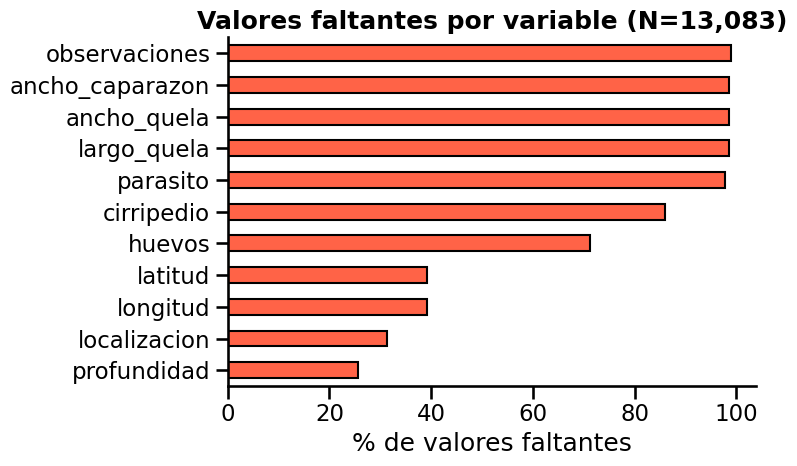

observaciones      98.91
ancho_caparazon    98.62
largo_quela        98.51
ancho_quela        98.51
parasito           97.75
cirripedio         85.94
huevos             71.29
longitud           39.27
latitud            39.27
localizacion       31.26
profundidad        25.58
dtype: float64

In [4]:
# Valores faltantes por variable
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
faltantes = faltantes[faltantes > 0].round(2)

fig, ax = plt.subplots(figsize=(8, 5))
faltantes.sort_values().plot(kind='barh', ax=ax, color='tomato', edgecolor='black')
ax.set_xlabel('% de valores faltantes')
ax.set_title(f'Valores faltantes por variable (N={len(df_raw):,})', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()
faltantes

Normalizamos el texto de `localizacion` (mayúsculas/espacios) para que las agrupaciones por lugar sean consistentes, y extraemos de `tipo` el número de trampas equivalentes de cada evento de muestreo (usado más adelante para el esfuerzo de pesca).

In [5]:
def normalizar_localizacion(s):
    if pd.isna(s):
        return np.nan
    return re.sub(r'\s+', ' ', str(s).strip().lower())

df_raw['localizacion_norm'] = df_raw['localizacion'].apply(normalizar_localizacion)

def extraer_num_trampas(tipo_str):
    # Extrae el numero de trampas equivalentes desde 'tipo' (1 linea = 10 trampas).
    if pd.isna(tipo_str):
        return np.nan
    texto = str(tipo_str).lower()
    match = re.search(r'(\d+\.?\d*)', texto)
    if not match:
        return np.nan
    numero = float(match.group(1))
    if 'trampa' in texto:
        return numero
    elif 'linea' in texto or 'línea' in texto:
        return numero * 10
    return np.nan

df_raw['num_trampas'] = df_raw['tipo'].apply(extraer_num_trampas)
print("Localizaciones unicas normalizadas:", df_raw['localizacion_norm'].nunique())
print("Eventos con numero de trampas identificable:", df_raw['num_trampas'].notna().sum())

Localizaciones unicas normalizadas: 62
Eventos con numero de trampas identificable: 9678


Imputamos coordenadas faltantes con la mediana de latitud/longitud de cada localización.

In [6]:
df_raw['coord_imputada'] = df_raw['latitud'].isna() | df_raw['longitud'].isna()
df_raw['latitud'] = df_raw['latitud'].fillna(df_raw.groupby('localizacion_norm')['latitud'].transform('median'))
df_raw['longitud'] = df_raw['longitud'].fillna(df_raw.groupby('localizacion_norm')['longitud'].transform('median'))

recuperadas = (df_raw['coord_imputada'] & df_raw['latitud'].notna()).sum()
sin_recuperar = df_raw['latitud'].isna().sum()
print(f"Coordenadas recuperadas por mediana de grupo: {recuperadas}")
print(f"Registros que siguen sin coordenadas (sin ninguna referencia previa en su localizacion): {sin_recuperar}")

Coordenadas recuperadas por mediana de grupo: 25
Registros que siguen sin coordenadas (sin ninguna referencia previa en su localizacion): 5113


Limpiamos `huevos`, `parasito` y `cirripedio`: son variables categóricas codificadas con números, pero algunas filas tienen texto libre o typos (por ejemplo `"conojos"`, `"po"`, o un cero de más como `"30"` en vez de `"3"`). Una función auxiliar homogeneiza estos valores a su código numérico correspondiente (0 a 7 para huevos, según el diccionario de datos del proyecto).

Para `huevos`, agrupamos los 8 códigos en tres estados según lo acordado con el grupo: **sin huevos** (0, 5, 6, 7), **con huevos** (1, 2, 3) y **eclosionado** (4).

In [7]:
def limpiar_huevos(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float, np.integer, np.floating)):
        num = float(val)
    else:
        s = str(val).strip().lower()
        if s == 'conojos':      # "con ojos" -> huevos con ojos
            return 3.0
        if s == 'po':           # "poca(s)" -> poca cantidad de huevos
            return 7.0
        m = re.match(r'^(\d+)', s)
        if not m:
            return np.nan
        num = float(m.group(1))
    if num in (30.0, 40.0):     # typo de un cero de mas
        return num / 10.0
    if 0.0 <= num <= 7.0:
        return num
    return np.nan

correcciones_parasito = {'3,20': '3', '30,20': '30'}     # se prioriza el parasito activo sobre la cicatriz
correcciones_cirripedio = {'2p': '2', '1p': '1', '3p': '3', 2.3: 2, 1.23: 1, 1.2: 1}

df_raw['huevos'] = df_raw['huevos'].apply(limpiar_huevos)
df_raw['parasito'] = df_raw['parasito'].replace(correcciones_parasito).apply(lambda x: float(x) if pd.notna(x) else np.nan)
df_raw['cirripedio'] = df_raw['cirripedio'].replace(correcciones_cirripedio).apply(lambda x: float(x) if pd.notna(x) else np.nan)
df_raw['estado_caparazon'] = df_raw['estado_caparazon'].astype('Int64')

huevos_map = {0: 'Sin huevos', 1: 'Con huevos', 2: 'Con huevos', 3: 'Con huevos',
              4: 'Eclosionado', 5: 'Sin huevos', 6: 'Sin huevos', 7: 'Sin huevos'}

print("huevos (tras limpieza):")
print(df_raw['huevos'].value_counts().sort_index())

huevos (tras limpieza):
huevos
0.0     936
1.0    1440
2.0       1
3.0     830
4.0      56
5.0     273
6.0     100
7.0     120
Name: count, dtype: int64


Explicitamos la codificación de especie y sexo.

In [8]:
especie_nombre = {1: 'Lithodes santolla (centolla)', 2: 'Paralomis granulosa (centollón)'}
df_raw['especie_nombre'] = df_raw['especie'].map(especie_nombre)
df_raw['sexo_nombre'] = df_raw['sexo'].map({1: 'Macho', 2: 'Hembra'})

n_especie = df_raw['especie'].value_counts()
print(f"Lithodes santolla (centolla):     {n_especie.get(1,0):>6,} registros")
print(f"Paralomis granulosa (centollón):  {n_especie.get(2,0):>6,} registros")
print("\nPor el tamaño muestral tan dispar, las preguntas 2 y 3 (huevos, hembras) se "
      "resuelven sobre Paralomis granulosa (centollón), que tiene volumen suficiente "
      "para desagregar por campaña y localización. La pregunta 1 sí compara ambas especies.")

Lithodes santolla (centolla):        433 registros
Paralomis granulosa (centollón):  12,650 registros

Por el tamaño muestral tan dispar, las preguntas 2 y 3 (huevos, hembras) se resuelven sobre Paralomis granulosa (centollón), que tiene volumen suficiente para desagregar por campaña y localización. La pregunta 1 sí compara ambas especies.


In [9]:
orden_campanas = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']
df_raw['fecha'] = pd.Categorical(df_raw['fecha'], categories=orden_campanas, ordered=True)
print("Dataset base listo:", df_raw.shape)

Dataset base listo: (13083, 23)


## Pregunta 1 (TP1): ¿Cuál fue la evolución temporal en la pesca de cada especie?

**Planteo e implicancias.** El proyecto se llama "¿Cuándo y dónde pescar *centollas*?", pero el dataset mezcla dos especies con historias biológicas y pesqueras distintas: *Lithodes santolla* (la centolla propiamente dicha, la especie de mayor valor comercial) y *Paralomis granulosa* (el centollón, mucho más abundante en las muestras). Si una de las dos especies estuviera perdiendo presencia relativa campaña a campaña, sería una señal temprana de sobreexplotación que un análisis que las trate como "centollas" en conjunto no puede detectar. Por eso esta pregunta pide explícitamente la evolución "de cada especie", no del conjunto.

**Desarrollo.** No hace falta filtrar por coordenadas ni por localización para esta pregunta (es puramente temporal), así que se usa `df_raw` completo. Se cuenta la cantidad de individuos registrados por campaña y especie, y se calcula además el porcentaje que representa *Lithodes santolla* sobre el total muestreado en cada campaña (para ver si su participación relativa cambia, más allá del volumen absoluto).

In [10]:
tab_especie = pd.crosstab(df_raw['fecha'], df_raw['especie_nombre']).reindex(orden_campanas)
share_centolla = (tab_especie['Lithodes santolla (centolla)'] / tab_especie.sum(axis=1) * 100).round(2)

print(tab_especie)
print("\n% de Lithodes santolla sobre el total muestreado, por campaña:")
print(share_centolla)

especie_nombre  Lithodes santolla (centolla)  Paralomis granulosa (centollón)
fecha                                                                        
ene_96                                    60                             1743
abril_96                                   0                              920
jul_96                                    39                             1806
oct_96                                   102                             1316
jul_97                                   125                             1937
oct_97                                    18                             2570
oct_98                                    89                             2358

% de Lithodes santolla sobre el total muestreado, por campaña:
fecha
ene_96      3.33
abril_96    0.00
jul_96      2.11
oct_96      7.19
jul_97      6.06
oct_97      0.70
oct_98      3.64
dtype: float64


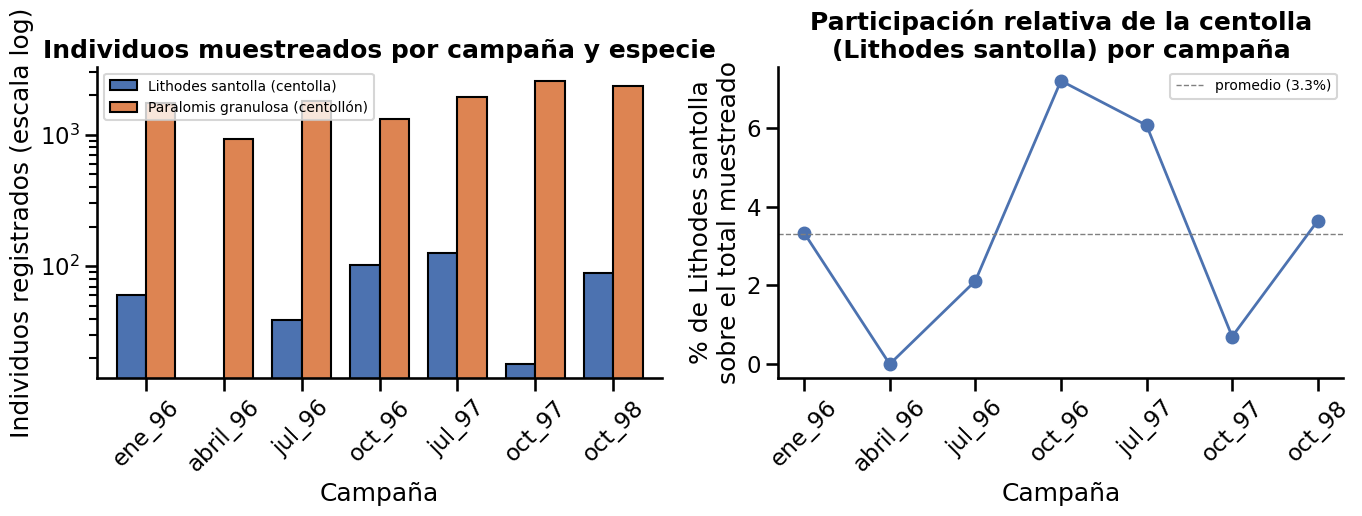

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

tab_especie.plot(kind='bar', ax=axes[0], color=['#4c72b0', '#dd8452'], edgecolor='black', width=0.75)
axes[0].set_yscale('log')
axes[0].set_ylabel('Individuos registrados (escala log)')
axes[0].set_xlabel('Campaña')
axes[0].set_title('Individuos muestreados por campaña y especie', fontweight='bold')
axes[0].legend(title='', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(orden_campanas, share_centolla.values, marker='o', color='#4c72b0', linewidth=2)
axes[1].set_ylabel('% de Lithodes santolla\nsobre el total muestreado')
axes[1].set_xlabel('Campaña')
axes[1].set_title('Participación relativa de la centolla\n(Lithodes santolla) por campaña', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(share_centolla.mean(), color='gray', linestyle='--', linewidth=1, label=f'promedio ({share_centolla.mean():.1f}%)')
axes[1].legend(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

**Interpretación.** *Paralomis granulosa* (centollón) domina el muestreo en las 7 campañas por uno o dos órdenes de magnitud (nótese la escala logarítmica del panel izquierdo): esto confirma la decisión de concentrar el resto del análisis en esa especie por volumen muestral. *Lithodes santolla* nunca desaparece del todo, pero su participación relativa es baja y oscila entre 0% (abril_96, sin ningún registro de centolla) y ~7% (oct_96), sin una tendencia claramente creciente o decreciente en el período 1996-1998: con solo 433 registros en total repartidos en 7 campañas, no alcanza para distinguir una tendencia real de ruido muestral. La recomendación práctica es que, si se quiere responder específicamente sobre el estado de la centolla (Lithodes santolla) y no solo del centollón, hace falta un muestreo dirigido a esa especie — este dataset no tiene la potencia estadística para eso.

## Pregunta 2 (TP1): ¿Cuándo se encontraron más huevos en las hembras?

**Planteo e implicancias.** Saber en qué campaña(s) hay más hembras con huevos permite recomendar una veda estacional que proteja el período reproductivo, cuando la especie es más vulnerable a la sobrepesca. Esta pregunta tiene una implicancia directa en el manejo pesquero: si se conoce la época de mayor actividad reproductiva, se puede prohibir la pesca (o exigir la devolución de hembras ovígeras) específicamente en esa ventana, en vez de aplicar una restricción uniforme todo el año.

**Desarrollo.** Se trabaja sobre hembras de *Paralomis granulosa* con dato válido de `huevos` (no se exige localización ni coordenadas, porque no hacen falta para esta pregunta). Se usa la agrupación de estados definida en la limpieza (sin huevos / con huevos / eclosionado) y se calcula, por campaña, el porcentaje de hembras en cada estado.

In [12]:
hembras = df_raw[(df_raw['especie'] == 2) & (df_raw['sexo'] == 2) & (df_raw['huevos'].notna())].copy()
hembras['estado_huevos'] = hembras['huevos'].map(huevos_map)
print(f"N hembras de centollón con dato de huevos: {len(hembras):,}")

n_por_campana = hembras.groupby('fecha', observed=False).size().reindex(orden_campanas)
tab_estado = pd.crosstab(hembras['fecha'], hembras['estado_huevos'], normalize='index').mul(100).reindex(orden_campanas)
tab_estado

N hembras de centollón con dato de huevos: 3,588


estado_huevos,Con huevos,Eclosionado,Sin huevos
fecha,,,
ene_96,71.146953,0.179211,28.673835
abril_96,62.650602,3.614458,33.734940
jul_96,40.176600,0.000000,59.823400
oct_96,38.481013,1.772152,59.746835
jul_97,73.734177,1.582278,24.683544
oct_97,67.544784,2.528978,29.926238
oct_98,63.218391,1.609195,35.172414


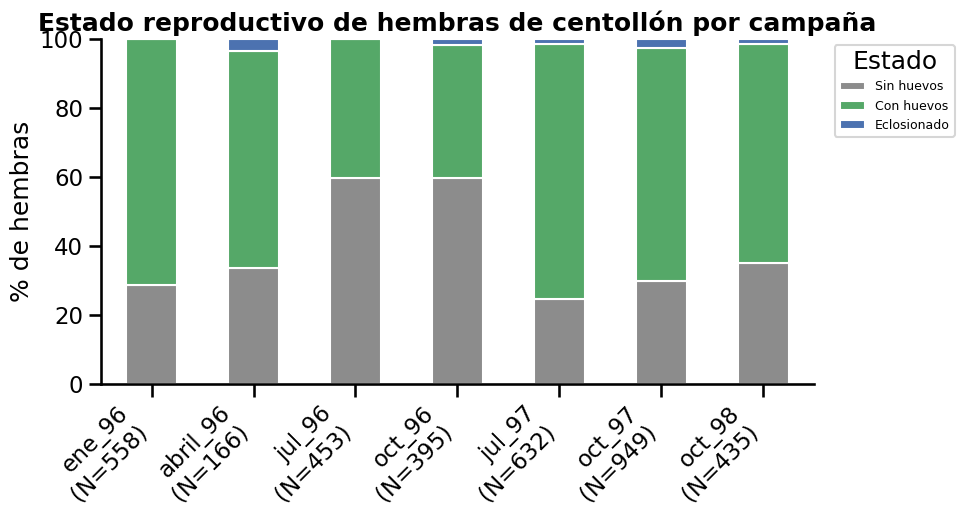

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))

tab_plot = tab_estado.reindex(columns=['Sin huevos', 'Con huevos', 'Eclosionado']).fillna(0)
tab_plot.plot(kind='bar', stacked=True, ax=ax, color=['#8c8c8c', '#55a868', '#4c72b0'], edgecolor='white')

etiquetas = [f"{t}\n(N={int(n_por_campana[t])})" for t in orden_campanas]
ax.set_xticklabels(etiquetas, rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('% de hembras')
ax.set_title('Estado reproductivo de hembras de centollón por campaña', fontweight='bold')
ax.legend(title='Estado', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

**Interpretación.** Las campañas de **enero, julio (ambos años) y octubre_97** muestran la mayor proporción de hembras con huevos (>60-70%), mientras que **julio_96 y octubre_96** muestran los valores más bajos (~38-40%). Esto es coherente con un patrón reproductivo estacional marcado más que aleatorio. La implicancia de manejo es concreta: si se va a recomendar una veda reproductiva, las campañas de enero/julio/octubre-97 son las candidatas naturales por concentrar la mayor proporción de hembras ovígeras.

## Pregunta 3 (TP1): ¿Dónde se pescaron mayor cantidad de hembras con huevos en estos períodos?

**Planteo e implicancias.** Además de restringir la pesca en el tiempo (pregunta 2), se puede restringir en el espacio: si ciertas localizaciones concentran una proporción mucho mayor de hembras ovígeras que otras, esas zonas son candidatas a una veda espacial (o a una recomendación de liberar hembras ovígeras específicamente ahí), sin necesidad de cerrar toda la pesquería.

**Desarrollo.** Se agrupa por `localizacion_norm` a las hembras de centollón con coordenadas válidas y dato de huevos, se calcula la tasa de hembras con huevos, y se exige un mínimo de 5 hembras por localización para no graficar tasas basadas en 1 o 2 casos.

In [14]:
hembras_geo = df_raw[(df_raw['especie']==2) & (df_raw['sexo']==2)].dropna(subset=['latitud','longitud']).copy()
hembras_geo = hembras_geo[hembras_geo['huevos'].notna()]
hembras_geo['con_huevos'] = hembras_geo['huevos'].map(huevos_map) == 'Con huevos'

agg_loc = hembras_geo.groupby('localizacion_norm').agg(
    lat=('latitud', 'median'),
    lon=('longitud', 'median'),
    n_hembras=('con_huevos', 'size'),
    n_con_huevos=('con_huevos', 'sum'),
).reset_index()
agg_loc = agg_loc[agg_loc['n_hembras'] >= 5].copy()
agg_loc['tasa_con_huevos_%'] = (agg_loc['n_con_huevos'] / agg_loc['n_hembras'] * 100).round(1)
agg_loc = agg_loc.sort_values('tasa_con_huevos_%', ascending=False).reset_index(drop=True)

print(f"Localizaciones con al menos 5 hembras muestreadas: {len(agg_loc)}")
agg_loc

Localizaciones con al menos 5 hembras muestreadas: 43


,localizacion_norm,lat,lon,n_hembras,n_con_huevos,tasa_con_huevos_%
0,wp 61,-54.901683,-67.195083,5,5,100.0
1,wp 154,-54.864983,-67.877283,136,125,91.9
2,wp 150,-54.858083,-68.039783,34,30,88.2
3,wp 241,-54.886967,-67.711850,38,33,86.8
4,al s de baliza de e. remolino,-54.869617,-67.860617,117,96,82.1
5,wp 165,-54.908433,-67.196817,93,75,80.6
6,wp 242,-54.889667,-67.696800,41,33,80.5
7,wp 236,-54.886100,-67.602967,116,93,80.2
8,wp 172,-54.929283,-67.064200,199,159,79.9
9,wp 167,-54.907317,-67.332417,50,36,72.0


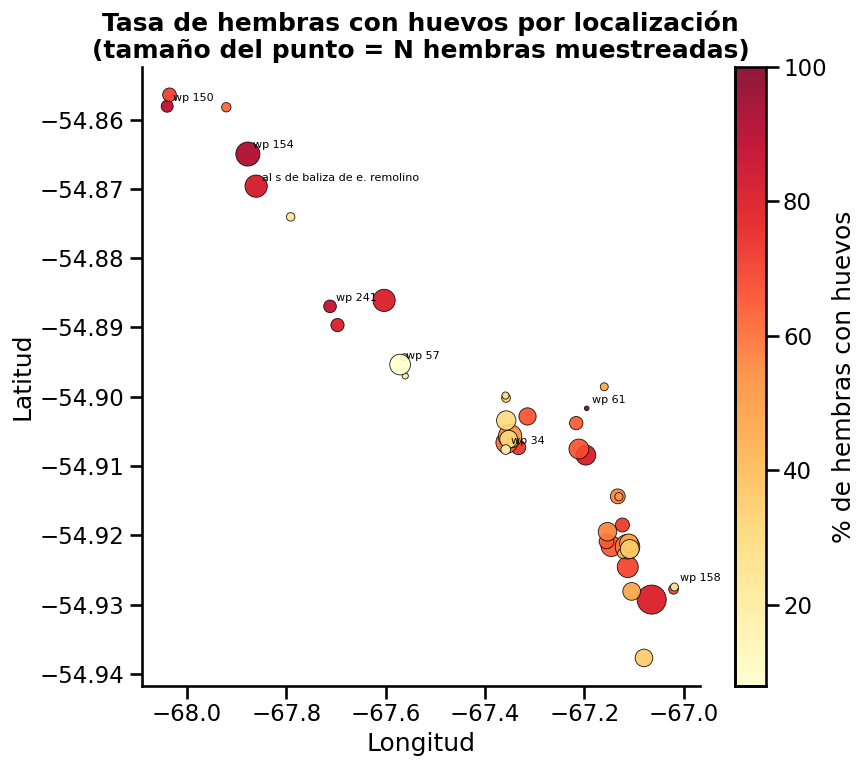

In [15]:
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(agg_loc['lon'], agg_loc['lat'], s=agg_loc['n_hembras']*2.2,
                 c=agg_loc['tasa_con_huevos_%'], cmap='YlOrRd', edgecolor='black', linewidth=0.6, alpha=0.9)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('% de hembras con huevos')

top5 = agg_loc.head(5)
bottom3 = agg_loc.tail(3)
for _, r in pd.concat([top5, bottom3]).iterrows():
    ax.annotate(r['localizacion_norm'], (r['lon'], r['lat']), fontsize=8,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Tasa de hembras con huevos por localización\n(tamaño del punto = N hembras muestreadas)', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación.** La tasa de hembras con huevos varía fuertemente según la localización: desde valores bajos (~8-14%, wp 57 y wp 34) hasta más de 80% en localizaciones con buen volumen muestral (wp 154 con 92%, wp 236 y wp 172 alrededor de 80%, todas con más de 100 hembras). Las localizaciones etiquetadas como `wp 1xx`-`wp 2xx` en general muestran tasas más altas que `wp 30`-`wp 35` y `wp 57`/`wp 58`, lo que sugiere una diferencia espacial real (no solo ruido muestral, dado el N de cada grupo) entre zonas de cría/reproducción y zonas de alimentación o paso. Estas localizaciones de alta tasa (`wp 154`, `wp 236`, `wp 241`, `wp 242`, `wp 172`) son las candidatas más claras a una restricción espacial de pesca durante la temporada reproductiva.

## Síntesis: ¿dónde y cuándo no pescar? (pregunta 5 del TP1)

Combinando las preguntas 2 y 3: las campañas de **enero, julio (ambos años) y octubre_97** concentran la mayor proporción de hembras de centollón con huevos, y dentro de esas campañas las localizaciones **wp 154, wp 236, wp 241, wp 242 y wp 172** muestran las tasas más altas de hembras ovígeras con volumen muestral suficiente. Una recomendación de manejo basada en estos datos sería restringir la pesca (o exigir liberación de hembras) específicamente en esas localizaciones durante esas campañas, en lugar de aplicar una veda general todo el año en toda el área. Para *Lithodes santolla* (pregunta 1), el volumen de datos disponible (433 registros) no alcanza para una recomendación espacial o temporal propia con la misma confianza.

## Análisis complementarios

Estos análisis no son necesarios para responder las tres preguntas elegidas, pero aportan contexto adicional sobre el dataset: un mapa de las localizaciones (ya incluido en la pregunta 3), la imputación de profundidad usando la posición geográfica, una comparación del tamaño de caparazón entre especies y sexos, y una comparación entre el esfuerzo de pesca y la cantidad de individuos capturados por campaña.

In [16]:
# Imputacion de profundidad con los 5 vecinos mas cercanos en lat/lon
falt_antes = df_raw['profundidad'].isna().sum()

con_coords = df_raw.dropna(subset=['latitud', 'longitud'])
train = con_coords[con_coords['profundidad'].notna()]
falta = df_raw[df_raw['profundidad'].isna() & df_raw['latitud'].notna() & df_raw['longitud'].notna()]

if len(train) > 0 and len(falta) > 0:
    nn = NearestNeighbors(n_neighbors=5).fit(train[['latitud', 'longitud']])
    _, idx = nn.kneighbors(falta[['latitud', 'longitud']])
    df_raw.loc[falta.index, 'profundidad'] = train['profundidad'].values[idx].mean(axis=1)

falt_despues = df_raw['profundidad'].isna().sum()
print(f"Faltantes de 'profundidad' antes: {falt_antes} | despues de imputar por 5 vecinos mas cercanos (lat/lon): {falt_despues}")
print("(quedan sin imputar los registros que tampoco tienen coordenadas: no hay de donde tomar una referencia espacial)")

Faltantes de 'profundidad' antes: 3346 | despues de imputar por 5 vecinos mas cercanos (lat/lon): 3233
(quedan sin imputar los registros que tampoco tienen coordenadas: no hay de donde tomar una referencia espacial)


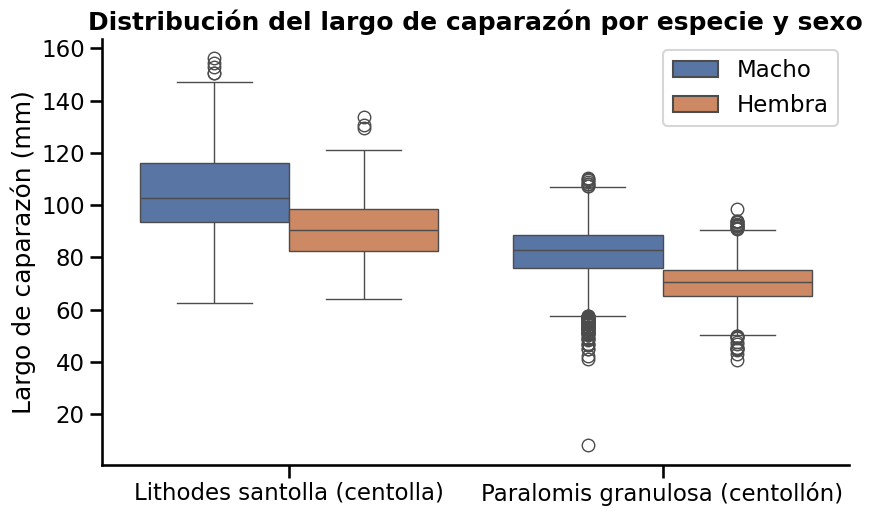

count   mean   std   min    50%  \
especie_nombre                  sexo_nombre                                     
Lithodes santolla (centolla)    Hembra        160.0   91.7  12.7  64.2   90.6   
                                Macho         273.0  105.3  18.8  62.6  102.9   
Paralomis granulosa (centollón) Hembra       3666.0   70.3   7.5  40.9   70.5   
                                Macho        8984.0   82.1   9.3   8.1   82.8   

                                               max  
especie_nombre                  sexo_nombre         
Lithodes santolla (centolla)    Hembra       133.8  
                                Macho        156.2  
Paralomis granulosa (centollón) Hembra        98.4  
                                Macho        110.2

In [17]:
# EDA de largo_caparazon por especie y sexo
fig, ax = plt.subplots(figsize=(9, 5.5))
orden_box = ['Lithodes santolla (centolla)', 'Paralomis granulosa (centollón)']
sns.boxplot(data=df_raw, x='especie_nombre', y='largo_caparazon', hue='sexo_nombre',
            order=orden_box, palette=['#4c72b0', '#dd8452'], ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Largo de caparazón (mm)')
ax.set_title('Distribución del largo de caparazón por especie y sexo', fontweight='bold')
ax.legend(title='')
sns.despine()
plt.tight_layout()
plt.show()

df_raw.groupby(['especie_nombre', 'sexo_nombre'], observed=False)['largo_caparazon'].describe()[['count','mean','std','min','50%','max']].round(1)

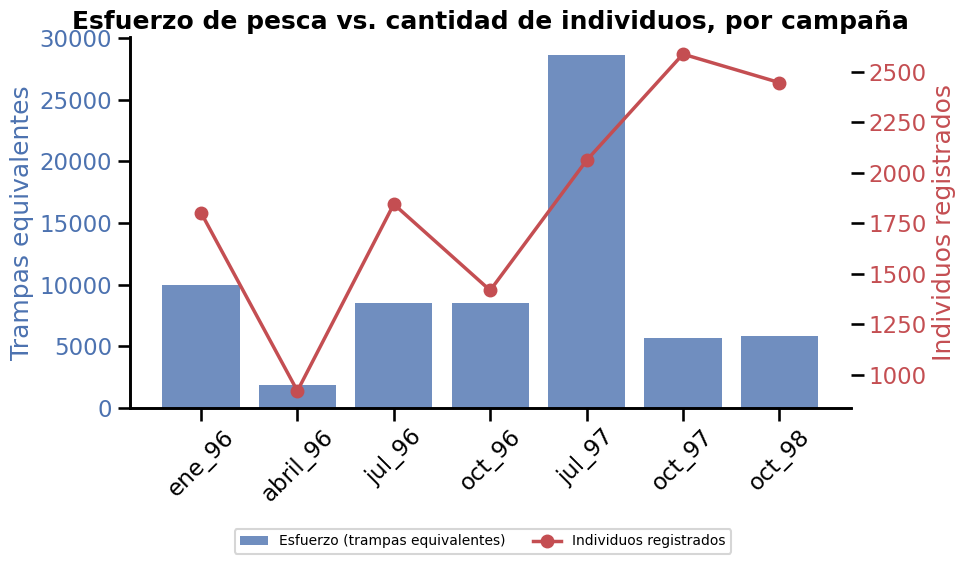

In [18]:
# Esfuerzo de pesca (trampas equivalentes) vs cantidad de individuos, por campana
esfuerzo = df_raw.dropna(subset=['num_trampas']).groupby('fecha', observed=False)['num_trampas'].sum().reindex(orden_campanas)
individuos = df_raw.groupby('fecha', observed=False).size().reindex(orden_campanas)

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.bar(orden_campanas, esfuerzo.values, color='#4c72b0', alpha=0.8, label='Esfuerzo (trampas equivalentes)')
ax1.set_ylabel('Trampas equivalentes', color='#4c72b0')
ax1.tick_params(axis='y', labelcolor='#4c72b0')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(orden_campanas, individuos.values, color='#c44e52', marker='o', linewidth=2.5, label='Individuos registrados')
ax2.set_ylabel('Individuos registrados', color='#c44e52')
ax2.tick_params(axis='y', labelcolor='#c44e52')

ax1.set_title('Esfuerzo de pesca vs. cantidad de individuos, por campaña', fontweight='bold')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación de los análisis complementarios.** El caparazón de *Lithodes santolla* es sistemáticamente más grande que el de *Paralomis granulosa* en ambos sexos (medianas ~91-103mm vs ~70-83mm), y en las dos especies los machos superan a las hembras en tamaño — consistente con lo esperado biológicamente para lithódidos. En el gráfico de esfuerzo vs. captura, **julio_97** combina el mayor esfuerzo de pesca (más trampas equivalentes) con una captura moderada, mientras que **octubre_97 y octubre_98** logran más individuos registrados con menos esfuerzo relativo — es decir, mayor eficiencia de captura (más individuos por trampa), lo cual es coherente con ser también las campañas de mayor actividad reproductiva encontradas en la pregunta 2.

## Conclusiones y limitaciones

- Las preguntas 1, 2 y 3 del TP1 quedaron respondidas con el planteo, desarrollo, gráfico e interpretación pedidos por la consigna, y la síntesis final conecta los resultados con la pregunta 5 (dónde y cuándo no pescar).
- **Limitación de tamaño muestral:** cualquier conclusión sobre *Lithodes santolla* (centolla) es débil por tener solo 433 registros; este dataset está mejor preparado para conclusiones sobre *Paralomis granulosa* (centollón).
- **Limitación temporal:** los datos van de 1996 a 1998. Cualquier recomendación de manejo pesquero basada en este análisis debería contrastarse con datos más recientes antes de aplicarse.
- **Próximo paso posible:** cruzar estos resultados con la talla mínima legal de captura de la especie, para acotar el análisis a la fracción de la población efectivamente capturable.